In [1]:
import gzip
import io
import json
import math
import os
import random
import re
import sys
import time
from collections import Counter, defaultdict

import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
ASSIGNMENT3_DATA = os.path.join("..", "Assignment - 3", "data")

print("python:", sys.version.split()[0])

python: 3.11.9


In [2]:
CONFIG = {
    # how much of the Assignment 3 training split to train the LMs on.
    # 1000000 = the whole thing, as the assignment specifies.
    "lm_train_sentences": 1000000,

    "max_order": 4,                 # unigram .. quadgram
    "min_count": 2,                 # words rarer than this in training become <unk>

    "d": 0.75,                      # Kneser-Ney discount, fixed by the assignment
    "unigram_lambda": 1.0,          # lambda in (c(w) + lambda) / (N + lambda V)

    # hyper-parameter searches, both run on the development set
    "add_k_grid": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
    "lambda_grid": [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
    "interp_rounds": 3,             # coordinate-descent sweeps over the interpolation weights
}

BOS, EOS, UNK = "<s>", "</s>", "<unk>"
CONFIG

{'lm_train_sentences': 1000000,
 'max_order': 4,
 'min_count': 2,
 'd': 0.75,
 'unigram_lambda': 1.0,
 'add_k_grid': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
 'lambda_grid': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
 'interp_rounds': 3}

In [3]:
def load_split(directory, name):
    path = os.path.join(directory, "gu_%s.txt" % name)
    if not os.path.exists(path):
        return None
    with io.open(path, encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f if line.strip()]


def load_all(directory):
    out = {}
    for name in ("train", "dev", "test"):
        part = load_split(directory, name)
        if part is None:
            return None
        out[name] = part
    return out


splits = load_all(ASSIGNMENT3_DATA) or load_all(DATA_DIR)
print("found the Assignment 3 splits" if splits else
      "Assignment 3 splits not found - they will be rebuilt below")

found the Assignment 3 splits


In [4]:
if splits is None:
    # ---- identical to Assignment 3: stream, sentence-tokenize, length-stratified split ----
    from huggingface_hub import HfApi, hf_hub_url
    import requests

    try:
        from huggingface_hub import get_token
    except ImportError:
        from huggingface_hub import HfFolder

        def get_token():
            return HfFolder.get_token()

    REPO_ID = "ai4bharat/IndicCorpV2"
    DANDA, DOUBLE_DANDA = "।", "॥"
    HARD_STOPS = DANDA + DOUBLE_DANDA + "…" + "!?"
    _HARD_SPLIT = re.compile(r"(?<=[" + re.escape(HARD_STOPS) + r"])\s+|\n+")
    _DOT_SPLIT = re.compile(r"(?<![A-Z]\.)(?<!\d\.)(?<=\.)\s+(?!\d)")
    _WS = re.compile(r"\s+")
    _URL = re.compile(r"https?://\S+|www\.\S+|\S+@\S+\.\S+")
    GUJARATI = "઀-૿"
    _GU_CHAR = re.compile("[" + GUJARATI + "]")
    N_DEV = N_TEST = 1000
    TOTAL = CONFIG["lm_train_sentences"] + N_DEV + N_TEST

    def sentence_tokenize(paragraph):
        paragraph = _URL.sub(" ", paragraph)
        out = []
        for chunk in _HARD_SPLIT.split(paragraph):
            for piece in _DOT_SPLIT.split(chunk) if chunk else ():
                piece = _WS.sub(" ", piece).strip()
                if piece:
                    out.append(piece)
        return out

    def acceptable(s):
        n = len(s)
        if n < 15 or n > 400 or s.count(" ") + 1 < 3:
            return False
        return len(_GU_CHAR.findall(s)) / n >= 0.5

    files = HfApi().list_repo_files(REPO_ID, repo_type="dataset")
    pat = re.compile(r"(?:^|/)(gu(?:[_-][A-Za-z]{4})?)\.txt(\.gz)?$")
    repo_path = min([p for p in files if pat.search(p)], key=len)
    print("streaming", repo_path)

    url = hf_hub_url(REPO_ID, repo_path, repo_type="dataset")
    token = get_token()
    headers = {"Authorization": "Bearer " + token} if token else {}
    seen, kept = set(), []
    with requests.get(url, headers=headers, stream=True, timeout=120) as resp:
        resp.raise_for_status()
        raw = gzip.GzipFile(fileobj=resp.raw) if repo_path.endswith(".gz") else resp.raw
        reader = io.TextIOWrapper(raw, encoding="utf-8", errors="ignore")
        for line in reader:
            for s in sentence_tokenize(line):
                if s not in seen and acceptable(s):
                    seen.add(s)
                    kept.append(s)
            if len(kept) >= TOTAL:
                break
    kept = kept[:TOTAL]
    print("collected", len(kept), "sentences")

    lengths = np.array([s.count(" ") + 1 for s in kept])
    edges = np.quantile(lengths, np.linspace(0, 1, 11))
    edges[-1] += 1
    bin_of = np.clip(np.digitize(lengths, edges[1:-1]), 0, 9)
    rng = random.Random(SEED)
    buckets = defaultdict(list)
    for i, b in enumerate(bin_of):
        buckets[int(b)].append(i)
    dev_idx, test_idx = [], []
    for b in range(10):
        pool = buckets[b]
        rng.shuffle(pool)
        dev_idx += pool[:N_DEV // 10]
        test_idx += pool[N_DEV // 10:N_DEV // 10 + N_TEST // 10]
    held = set(dev_idx) | set(test_idx)
    train_idx = [i for i in range(len(kept)) if i not in held]
    splits = {"train": [kept[i] for i in train_idx],
              "dev": [kept[i] for i in dev_idx],
              "test": [kept[i] for i in test_idx]}
    for name, part in splits.items():
        with io.open(os.path.join(DATA_DIR, "gu_%s.txt" % name), "w", encoding="utf-8",
                     newline="\n") as f:
            f.write("\n".join(part))
    print("rebuilt and saved the splits")

In [5]:
train_sents = splits["train"][:CONFIG["lm_train_sentences"]]
dev_sents = splits["dev"]
test_sents = splits["test"]

print("train %d   dev %d   test %d" % (len(train_sents), len(dev_sents), len(test_sents)))
print("example:", train_sents[0][:90])

train 1000000   dev 1000   test 1000
example: તેઓ કહે છે કે અહીંની સંપત્તિ વેચવી એ માતાને વેચવા બરાબર હતું.


In [6]:
_PRETOK = re.compile("[઀-૿]+|[A-Za-z]+|[0-9]+|[^\\s]")


def tokenize(sentence):
    return _PRETOK.findall(sentence)


t0 = time.time()
train_tokens = [tokenize(s) for s in train_sents]
dev_tokens = [tokenize(s) for s in dev_sents]
test_tokens = [tokenize(s) for s in test_sents]
print("tokenized in %.0fs" % (time.time() - t0))

word_counts = Counter()
for toks in train_tokens:
    word_counts.update(toks)
print("distinct training words: {:,}".format(len(word_counts)))
print("running tokens        : {:,}".format(sum(word_counts.values())))

tokenized in 6s
distinct training words: 538,928
running tokens        : 17,135,144


In [7]:
VOCAB = {w for w, c in word_counts.items() if c >= CONFIG["min_count"]}
VOCAB.add(UNK)
VOCAB.add(EOS)
V = len(VOCAB)
print("vocabulary (min_count={}): {:,}".format(CONFIG["min_count"], V))
kept_mass = sum(c for w, c in word_counts.items() if c >= CONFIG["min_count"])
print("token coverage before <unk> mapping: {:.2f}%".format(
    100.0 * kept_mass / sum(word_counts.values())))


def to_vocab(tokens):
    return [w if w in VOCAB else UNK for w in tokens]


train_tokens = [to_vocab(t) for t in train_tokens]
dev_tokens = [to_vocab(t) for t in dev_tokens]
test_tokens = [to_vocab(t) for t in test_tokens]

for name, data in (("dev", dev_tokens), ("test", test_tokens)):
    n = sum(len(t) for t in data)
    u = sum(t.count(UNK) for t in data)
    print("{:<5} tokens {:,}  <unk> {:,}  ({:.2f}%)".format(name, n, u, 100.0 * u / n))

vocabulary (min_count=2): 235,324
token coverage before <unk> mapping: 98.23%
dev   tokens 16,491  <unk> 443  (2.69%)
test  tokens 16,471  <unk> 440  (2.67%)


In [8]:
def memory_note():
    try:
        import psutil
        return "  [RSS %.1f GB]" % (psutil.Process().memory_info().rss / 1e9)
    except Exception:
        return ""


class NgramCounts:
    """Every count statistic the five smoothing methods need, for orders 1..max_order."""

    def __init__(self, token_lists, max_order, verbose=True):
        self.max_order = max_order
        self.ngram = {n: Counter() for n in range(1, max_order + 1)}
        self.ctx_total = {n: Counter() for n in range(2, max_order + 1)}
        self.ctx_types = {n: Counter() for n in range(2, max_order + 1)}

        t0 = time.time()
        for idx, toks in enumerate(token_lists):
            padded = [BOS] * (max_order - 1) + toks + [EOS]
            start = max_order - 1
            for n in range(1, max_order + 1):
                gram = self.ngram[n]
                # only positions that predict a real token (or </s>) count
                for i in range(start, len(padded)):
                    key = tuple(padded[i - n + 1:i + 1])
                    gram[key] += 1
            if verbose and idx and idx % 200000 == 0:
                print("  %8d sentences%s" % (idx, memory_note()))

        # context totals and distinct-continuation counts follow from the n-gram tables
        for n in range(2, max_order + 1):
            total, types = self.ctx_total[n], self.ctx_types[n]
            for key, c in self.ngram[n].items():
                h = key[:-1]
                total[h] += c
                types[h] += 1
        self.total_tokens = sum(self.ngram[1].values())

        if verbose:
            print("counted in %.0fs%s" % (time.time() - t0, memory_note()))
            for n in range(1, max_order + 1):
                print("  {}-grams: {:>12,} distinct".format(n, len(self.ngram[n])))

    # ------------------------------------------------------------------ Kneser-Ney extras
    def build_continuation_counts(self, verbose=True):
        """N1+(. w_{1..n}) for n < max_order, plus its context sums - the KN lower orders."""
        t0 = time.time()
        self.cont = {}
        self.cont_total = {}
        self.cont_types = {}
        for n in range(1, self.max_order):
            cont = Counter()
            for key in self.ngram[n + 1]:
                cont[key[1:]] += 1          # one distinct left context for this suffix
            self.cont[n] = cont
            if n >= 2:
                total, types = Counter(), Counter()
                for key, c in cont.items():
                    h = key[:-1]
                    total[h] += c
                    types[h] += 1
                self.cont_total[n] = total
                self.cont_types[n] = types
            else:
                # N1+(..) - the total number of distinct bigram types
                self.cont_bigram_types = sum(cont.values())
                self.cont_unigram_types = len(cont)
        if verbose:
            print("continuation counts in %.0fs%s" % (time.time() - t0, memory_note()))
            print("  N1+(..) = distinct bigram types: {:,}".format(self.cont_bigram_types))
        return self


counts = NgramCounts(train_tokens, CONFIG["max_order"])

    200000 sentences  [RSS 2.9 GB]
    400000 sentences  [RSS 3.6 GB]
    600000 sentences  [RSS 4.3 GB]
    800000 sentences  [RSS 5.0 GB]
counted in 86s  [RSS 7.5 GB]
  1-grams:      235,324 distinct
  2-grams:    5,231,678 distinct
  3-grams:   11,102,844 distinct
  4-grams:   13,999,181 distinct


In [9]:
counts.build_continuation_counts()

continuation counts in 48s  [RSS 8.0 GB]
  N1+(..) = distinct bigram types: 5,231,678


In [10]:
class LanguageModel:
    """Base class: padding, the shared perplexity loop, and the prescribed unigram."""

    name = "base"

    def __init__(self, counts, order, cfg=CONFIG):
        self.c = counts
        self.order = order
        self.cfg = cfg
        self.V = V
        self.N = counts.total_tokens
        self.unigram_lambda = cfg["unigram_lambda"]

    # the formula the assignment prescribes for unigrams
    def unigram_prob(self, w, lam=None):
        lam = self.unigram_lambda if lam is None else lam
        return (self.c.ngram[1].get((w,), 0) + lam) / (self.N + lam * self.V)

    def logprob(self, context, w):
        raise NotImplementedError

    def perplexity(self, token_lists, return_detail=False):
        """exp(-mean log P). A single zero-probability token makes this infinite, by design."""
        total_lp = 0.0
        n_tokens = 0
        n_zero = 0
        NEG_INF = float("-inf")
        for toks in token_lists:
            padded = [BOS] * (self.order - 1) + toks + [EOS]
            for i in range(self.order - 1, len(padded)):
                lp = self.logprob(tuple(padded[i - self.order + 1:i]), padded[i])
                n_tokens += 1
                if lp == NEG_INF:
                    n_zero += 1
                else:
                    total_lp += lp
        pp = float("inf") if n_zero else math.exp(-total_lp / n_tokens)
        if return_detail:
            return pp, {"tokens": n_tokens, "zero_prob": n_zero,
                        "zero_pct": 100.0 * n_zero / n_tokens}
        return pp

    def perplexity_on_covered(self, token_lists):
        """Perplexity restricted to the tokens the model gives non-zero probability.

        Meaningless as a language-model score - it is only a diagnostic that makes the
        unsmoothed model's failure legible instead of just reporting `inf`.
        """
        total_lp, n = 0.0, 0
        for toks in token_lists:
            padded = [BOS] * (self.order - 1) + toks + [EOS]
            for i in range(self.order - 1, len(padded)):
                context = tuple(padded[i - self.order + 1:i])
                lp = self.logprob(context, padded[i])
                if lp > float("-inf"):
                    total_lp += lp
                    n += 1
        return math.exp(-total_lp / n) if n else float("inf")

In [11]:
class UnsmoothedLM(LanguageModel):
    name = "unsmoothed"

    def logprob(self, context, w):
        if self.order == 1:
            c = self.c.ngram[1].get((w,), 0)
            return math.log(c / self.N) if c else float("-inf")
        denom = self.c.ctx_total[self.order].get(context, 0)
        if denom == 0:
            return float("-inf")
        c = self.c.ngram[self.order].get(context + (w,), 0)
        return math.log(c / denom) if c else float("-inf")

In [12]:
class AddKLM(LanguageModel):
    def __init__(self, counts, order, k=1.0, cfg=CONFIG):
        LanguageModel.__init__(self, counts, order, cfg)
        self.k = k
        self.name = "add-one" if k == 1.0 else "add-k (k=%g)" % k

    def logprob(self, context, w):
        k, V_ = self.k, self.V
        if self.order == 1:
            return math.log((self.c.ngram[1].get((w,), 0) + k) / (self.N + k * V_))
        denom = self.c.ctx_total[self.order].get(context, 0) + k * V_
        num = self.c.ngram[self.order].get(context + (w,), 0) + k
        return math.log(num / denom)

In [13]:
class InterpolatedLM(LanguageModel):
    name = "interpolated"

    def __init__(self, counts, order, lambdas=None, cfg=CONFIG):
        LanguageModel.__init__(self, counts, order, cfg)
        # lambdas[n] is the weight of the order-n maximum-likelihood estimate
        self.lambdas = dict(lambdas) if lambdas else {n: 0.5 for n in range(2, order + 1)}

    def logprob(self, context, w):
        p = self.unigram_prob(w)
        for n in range(2, self.order + 1):
            h = context[self.order - n:]          # the last n-1 words of the context
            denom = self.c.ctx_total[n].get(h, 0)
            if not denom:
                # The context was never seen, so this order has no opinion. Skipping the level
                # (rather than mixing in a zero ML estimate) is what keeps the model a proper
                # distribution: mixing would silently discard (1 - lambda) of the mass here.
                continue
            ml = self.c.ngram[n].get(h + (w,), 0) / denom
            lam = self.lambdas[n]
            p = lam * ml + (1.0 - lam) * p
        return math.log(p) if p > 0 else float("-inf")

In [14]:
class KneserNeyLM(LanguageModel):
    name = "kneser-ney"

    def __init__(self, counts, order, d=None, cfg=CONFIG):
        LanguageModel.__init__(self, counts, order, cfg)
        self.d = cfg["d"] if d is None else d
        if not hasattr(counts, "cont"):
            counts.build_continuation_counts(verbose=False)

    def logprob(self, context, w):
        d = self.d
        p = self.unigram_prob(w)                  # prescribed unigram base

        if self.order == 1:
            return math.log(p)

        # lower orders (2 .. order-1) on continuation counts
        for n in range(2, self.order):
            h = context[self.order - n:]
            denom = self.c.cont_total[n].get(h, 0)
            if denom == 0:
                continue                          # unseen context: fall through unchanged
            num = max(self.c.cont[n].get(h + (w,), 0) - d, 0.0)
            back = d * self.c.cont_types[n].get(h, 0) / denom
            p = num / denom + back * p

        # highest order on ordinary counts
        h = context
        denom = self.c.ctx_total[self.order].get(h, 0)
        if denom > 0:
            num = max(self.c.ngram[self.order].get(h + (w,), 0) - d, 0.0)
            back = d * self.c.ctx_types[self.order].get(h, 0) / denom
            p = num / denom + back * p

        return math.log(p) if p > 0 else float("-inf")

In [15]:
def tune_add_k(order, grid=CONFIG["add_k_grid"], verbose=True):
    best_k, best_pp = None, float("inf")
    for k in grid:
        pp = AddKLM(counts, order, k=k).perplexity(dev_tokens)
        if verbose:
            print("    k=%-6g dev PP %12.2f" % (k, pp))
        if pp < best_pp:
            best_k, best_pp = k, pp
    return best_k, best_pp


# The unigram base is shared by the interpolated and Kneser-Ney models, so its lambda is
# tuned first, once, on the development set.
def tune_unigram_lambda(grid=None):
    grid = grid or (CONFIG["lambda_grid"] + [1.0, 2.0])
    best_lam, best_pp = None, float("inf")
    for lam in sorted(set(grid)):
        cfg = dict(CONFIG)
        cfg["unigram_lambda"] = lam
        pp = InterpolatedLM(counts, 1, {}, cfg).perplexity(dev_tokens)
        print("    lambda=%-6g dev PP %12.2f" % (lam, pp))
        if pp < best_pp:
            best_lam, best_pp = lam, pp
    return best_lam, best_pp


print("tuning the unigram lambda")
_lam, _pp = tune_unigram_lambda()
CONFIG["unigram_lambda"] = _lam
print("  -> lambda = %g (dev PP %.2f)\n" % (_lam, _pp))

ADD_K = {}
for order in range(1, CONFIG["max_order"] + 1):
    print("N=%d" % order)
    k, pp = tune_add_k(order)
    ADD_K[order] = k
    print("  -> best k = %g (dev PP %.2f)\n" % (k, pp))

tuning the unigram lambda
    lambda=0.05   dev PP      2647.83
    lambda=0.1    dev PP      2648.04
    lambda=0.2    dev PP      2648.51
    lambda=0.3    dev PP      2649.03
    lambda=0.4    dev PP      2649.61
    lambda=0.5    dev PP      2650.24
    lambda=0.6    dev PP      2650.92
    lambda=0.7    dev PP      2651.65
    lambda=0.8    dev PP      2652.41
    lambda=0.9    dev PP      2653.22
    lambda=0.95   dev PP      2653.64
    lambda=1      dev PP      2654.07
    lambda=2      dev PP      2664.27
  -> lambda = 0.05 (dev PP 2647.83)

N=1
    k=0.001  dev PP      2647.65
    k=0.005  dev PP      2647.66
    k=0.01   dev PP      2647.68
    k=0.05   dev PP      2647.83
    k=0.1    dev PP      2648.04
    k=0.2    dev PP      2648.51
    k=0.3    dev PP      2649.03
    k=0.5    dev PP      2650.24
    k=0.7    dev PP      2651.65
    k=0.9    dev PP      2653.22
  -> best k = 0.001 (dev PP 2647.65)

N=2
    k=0.001  dev PP       807.17
    k=0.005  dev PP       880.92
 

In [16]:
def tune_interpolation(order, grid=CONFIG["lambda_grid"], rounds=CONFIG["interp_rounds"],
                       verbose=True):
    """Coordinate descent over the per-order interpolation weights, scored on dev."""
    if order == 1:
        return {}, InterpolatedLM(counts, 1).perplexity(dev_tokens)
    lambdas = {n: 0.5 for n in range(2, order + 1)}
    best_pp = InterpolatedLM(counts, order, lambdas).perplexity(dev_tokens)
    for r in range(rounds):
        improved = False
        for n in range(order, 1, -1):
            for lam in grid:
                trial = dict(lambdas)
                trial[n] = lam
                pp = InterpolatedLM(counts, order, trial).perplexity(dev_tokens)
                if pp < best_pp - 1e-9:
                    best_pp, lambdas, improved = pp, trial, True
        if verbose:
            print("    round %d: dev PP %.2f  lambdas %s" %
                  (r + 1, best_pp, {n: round(v, 3) for n, v in lambdas.items()}))
        if not improved:
            break
    return lambdas, best_pp


INTERP = {}
for order in range(1, CONFIG["max_order"] + 1):
    print("N=%d" % order)
    lam, pp = tune_interpolation(order)
    INTERP[order] = lam
    print("  -> lambdas %s (dev PP %.2f)\n" % ({n: round(v, 3) for n, v in lam.items()}, pp))

N=1
  -> lambdas {} (dev PP 2647.83)

N=2
    round 1: dev PP 505.90  lambdas {2: 0.7}
    round 2: dev PP 505.90  lambdas {2: 0.7}
  -> lambdas {2: 0.7} (dev PP 505.90)

N=3
    round 1: dev PP 417.50  lambdas {2: 0.6, 3: 0.4}
    round 2: dev PP 415.53  lambdas {2: 0.6, 3: 0.3}
    round 3: dev PP 415.53  lambdas {2: 0.6, 3: 0.3}
  -> lambdas {2: 0.6, 3: 0.3} (dev PP 415.53)

N=4
    round 1: dev PP 406.69  lambdas {2: 0.6, 3: 0.3, 4: 0.1}
    round 2: dev PP 405.36  lambdas {2: 0.6, 3: 0.2, 4: 0.2}
    round 3: dev PP 405.36  lambdas {2: 0.6, 3: 0.2, 4: 0.2}
  -> lambdas {2: 0.6, 3: 0.2, 4: 0.2} (dev PP 405.36)



In [17]:
def build_models(order):
    return [
        ("1. unsmoothed", UnsmoothedLM(counts, order)),
        ("2. add-one", AddKLM(counts, order, k=1.0)),
        ("3. add-k (k=%g)" % ADD_K[order], AddKLM(counts, order, k=ADD_K[order])),
        ("4. interpolated", InterpolatedLM(counts, order, INTERP[order])),
        ("5. kneser-ney (d=%g)" % CONFIG["d"], KneserNeyLM(counts, order)),
    ]


results = []
for order in range(1, CONFIG["max_order"] + 1):
    for label, model in build_models(order):
        t0 = time.time()
        dev_pp, dev_detail = model.perplexity(dev_tokens, return_detail=True)
        test_pp, test_detail = model.perplexity(test_tokens, return_detail=True)
        row = {"order": order, "method": label,
               "dev_pp": dev_pp, "test_pp": test_pp,
               "dev_zero_pct": dev_detail["zero_pct"],
               "test_zero_pct": test_detail["zero_pct"],
               "sec": time.time() - t0}
        if math.isinf(test_pp):
            row["test_pp_covered"] = model.perplexity_on_covered(test_tokens)
            row["dev_pp_covered"] = model.perplexity_on_covered(dev_tokens)
        results.append(row)
        print("N=%d  %-22s dev %14s  test %14s" % (
            order, label,
            "inf" if math.isinf(dev_pp) else "%.2f" % dev_pp,
            "inf" if math.isinf(test_pp) else "%.2f" % test_pp))

N=1  1. unsmoothed          dev        2647.64  test        2614.91
N=1  2. add-one             dev        2654.07  test        2622.90
N=1  3. add-k (k=0.001)     dev        2647.65  test        2614.92
N=1  4. interpolated        dev        2647.83  test        2615.19
N=1  5. kneser-ney (d=0.75) dev        2647.83  test        2615.19
N=2  1. unsmoothed          dev            inf  test            inf
N=2  2. add-one             dev        5539.78  test        5124.05
N=2  3. add-k (k=0.001)     dev         807.17  test         689.97
N=2  4. interpolated        dev         505.90  test         446.62
N=2  5. kneser-ney (d=0.75) dev         447.58  test         393.60
N=3  1. unsmoothed          dev            inf  test            inf
N=3  2. add-one             dev       38377.26  test       35721.18
N=3  3. add-k (k=0.001)     dev        5887.74  test        4961.87
N=3  4. interpolated        dev         415.53  test         362.04
N=3  5. kneser-ney (d=0.75) dev         362.62  

In [18]:
ORDER_NAMES = {1: "unigram", 2: "bigram", 3: "trigram", 4: "quadgram"}


def fmt(x):
    return "inf" if math.isinf(x) else ("%.2f" % x)


head = "%-9s %-22s %14s %14s %11s" % ("N", "smoothing", "dev PP", "test PP", "zero-prob %")
print(head)
print("-" * len(head))
last = None
for r in results:
    if last is not None and r["order"] != last:
        print("-" * len(head))
    last = r["order"]
    print("%-9s %-22s %14s %14s %11.3f" % (
        "%d (%s)" % (r["order"], ORDER_NAMES[r["order"]]) if r["method"].startswith("1.") else "",
        r["method"], fmt(r["dev_pp"]), fmt(r["test_pp"]), r["test_zero_pct"]))

N         smoothing                      dev PP        test PP zero-prob %
--------------------------------------------------------------------------
1 (unigram) 1. unsmoothed                 2647.64        2614.91       0.000
          2. add-one                    2654.07        2622.90       0.000
          3. add-k (k=0.001)            2647.65        2614.92       0.000
          4. interpolated               2647.83        2615.19       0.000
          5. kneser-ney (d=0.75)        2647.83        2615.19       0.000
--------------------------------------------------------------------------
2 (bigram) 1. unsmoothed                     inf            inf      19.781
          2. add-one                    5539.78        5124.05       0.000
          3. add-k (k=0.001)             807.17         689.97       0.000
          4. interpolated                505.90         446.62       0.000
          5. kneser-ney (d=0.75)         447.58         393.60       0.000
----------------------

In [19]:
# the same numbers as a smoothing x order matrix (test perplexity)
methods = [r["method"] for r in results if r["order"] == 1]
print("%-24s" % "test perplexity", end="")
for order in range(1, CONFIG["max_order"] + 1):
    print("%14s" % ORDER_NAMES[order], end="")
print()
print("-" * (24 + 14 * CONFIG["max_order"]))
for i, method in enumerate(methods):
    label = re.sub(r"\s*\(.*\)", "", method)
    print("%-24s" % label, end="")
    for order in range(1, CONFIG["max_order"] + 1):
        r = results[(order - 1) * len(methods) + i]
        print("%14s" % fmt(r["test_pp"]), end="")
    print()

test perplexity                unigram        bigram       trigram      quadgram
--------------------------------------------------------------------------------
1. unsmoothed                  2614.91           inf           inf           inf
2. add-one                     2622.90       5124.05      35721.18      87520.68
3. add-k                       2614.92        689.97       4961.87      24687.84
4. interpolated                2615.19        446.62        362.04        352.30
5. kneser-ney                  2615.19        393.60        313.88        317.09


In [20]:
# what the unsmoothed model is actually doing
print("The unsmoothed model, in detail:\n")
print("%-9s %14s %14s %20s" % ("N", "zero-prob % dev", "zero-prob % test",
                               "test PP on covered"))
print("-" * 60)
for r in results:
    if not r["method"].startswith("1."):
        continue
    print("%-9s %14.3f %14.3f %20s" % (
        ORDER_NAMES[r["order"]], r["dev_zero_pct"], r["test_zero_pct"],
        "%.2f" % r["test_pp_covered"] if "test_pp_covered" in r else "-"))
print("\n'PP on covered' ignores every token the model assigns zero probability to. It is not a")
print("valid language-model score - it is only there to show that the raw counts are not")
print("useless, they are simply undefined wherever the evaluation data leaves the training data.")

The unsmoothed model, in detail:

N         zero-prob % dev zero-prob % test   test PP on covered
------------------------------------------------------------
unigram            0.000          0.000                    -
bigram            20.954         19.781                84.01
trigram           54.594         52.905                15.32
quadgram          73.100         71.415                13.99

'PP on covered' ignores every token the model assigns zero probability to. It is not a
valid language-model score - it is only there to show that the raw counts are not
useless, they are simply undefined wherever the evaluation data leaves the training data.


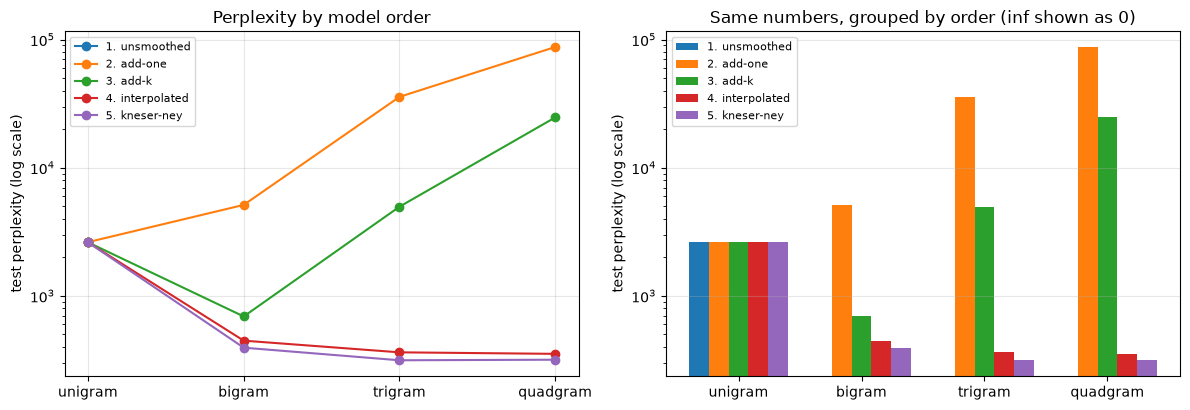

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
orders = list(range(1, CONFIG["max_order"] + 1))

for i, method in enumerate(methods):
    label = re.sub(r"\s*\(.*\)", "", method)
    ys = [results[(o - 1) * len(methods) + i]["test_pp"] for o in orders]
    if all(math.isinf(y) for y in ys):
        continue
    axes[0].plot(orders, ys, marker="o", label=label)
axes[0].set_xticks(orders)
axes[0].set_xticklabels([ORDER_NAMES[o] for o in orders])
axes[0].set_yscale("log")
axes[0].set_ylabel("test perplexity (log scale)")
axes[0].set_title("Perplexity by model order")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

width = 0.8 / len(methods)
x = np.arange(len(orders))
for i, method in enumerate(methods):
    label = re.sub(r"\s*\(.*\)", "", method)
    ys = [results[(o - 1) * len(methods) + i]["test_pp"] for o in orders]
    ys = [y if not math.isinf(y) else 0 for y in ys]
    axes[1].bar(x + i * width, ys, width, label=label)
axes[1].set_xticks(x + 0.4 - width / 2)
axes[1].set_xticklabels([ORDER_NAMES[o] for o in orders])
axes[1].set_yscale("log")
axes[1].set_ylabel("test perplexity (log scale)")
axes[1].set_title("Same numbers, grouped by order (inf shown as 0)")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

In [22]:
with io.open(os.path.join(DATA_DIR, "perplexities.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=1, default=str)
print("saved ->", os.path.join(DATA_DIR, "perplexities.json"))

saved -> data\perplexities.json


In [23]:
# (a) every smoothed model must be a proper distribution: sum_w P(w | h) = 1
sample_contexts = []
for toks in dev_tokens[:3]:
    padded = [BOS] * (CONFIG["max_order"] - 1) + toks + [EOS]
    for i in range(CONFIG["max_order"] - 1, min(len(padded), CONFIG["max_order"] + 2)):
        sample_contexts.append(tuple(padded[i - CONFIG["max_order"] + 1:i]))

vocab_list = sorted(VOCAB)
print("%-22s %-6s %s" % ("model", "N", "sum_w P(w|h) over the full vocabulary"))
print("-" * 70)
for order in (2, CONFIG["max_order"]):
    for label, model in build_models(order):
        if label.startswith("1."):
            continue          # unsmoothed sums to 1 only where the context was seen
        h = sample_contexts[0][-(order - 1):]
        total = sum(math.exp(model.logprob(h, w)) for w in vocab_list)
        print("%-22s %-6d %.10f" % (label, order, total))
        assert abs(total - 1.0) < 1e-6, "%s N=%d does not normalize (%.8f)" % (
            label, order, total)
print("\nall smoothed models normalize to 1")

model                  N      sum_w P(w|h) over the full vocabulary
----------------------------------------------------------------------
2. add-one             2      1.0000000000
3. add-k (k=0.001)     2      1.0000000000
4. interpolated        2      1.0000000000
5. kneser-ney (d=0.75) 2      1.0000000000
2. add-one             4      1.0000000000
3. add-k (k=0.001)     4      1.0000000000
4. interpolated        4      1.0000000000
5. kneser-ney (d=0.75) 4      1.0000000000

all smoothed models normalize to 1


In [24]:
# (b) perplexity computed the long way must match the model's own loop
def brute_force_perplexity(model, token_lists):
    logs = []
    for toks in token_lists:
        padded = [BOS] * (model.order - 1) + toks + [EOS]
        for i in range(model.order - 1, len(padded)):
            logs.append(model.logprob(tuple(padded[i - model.order + 1:i]), padded[i]))
    return math.exp(-sum(logs) / len(logs))


m = KneserNeyLM(counts, CONFIG["max_order"])
a = m.perplexity(test_tokens[:100])
b = brute_force_perplexity(m, test_tokens[:100])
print("Kneser-Ney N=%d  model loop %.4f  vs  brute force %.4f" % (CONFIG["max_order"], a, b))
assert abs(a - b) < 1e-6
print("perplexity loop verified")

Kneser-Ney N=4  model loop 260.9094  vs  brute force 260.9094
perplexity loop verified
